# Kahupuke Raw Hawaiian Sentence 
The Kahupuke Data is a comprehensive collection designed for 
exploring the intersections between Hawaiian and English 
languages through literature. 

Here we will we experiment with the preperations for a raw hawaiian corpus for BERT training

In [21]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
from pathlib import Path
from PIL import Image

In [22]:
from pathlib import Path
import sys

# Go up one directory (..), then into src/utils
UTILS_DIR = (Path.cwd().parent / "src" / "utils").resolve()
# → /home/jeraldy/haw-lm/src/utils

# Add it to the import search path
sys.path.insert(0, str(UTILS_DIR))

from text_utils import InternalState
api = InternalState()


In [23]:
from pathlib import Path
import sys

# Go up one directory (..), then into src/utils
UTILS_DIR = (Path.cwd().parent / "src" / "utils").resolve()
# → /home/jeraldy/haw-lm/src/utils

# Add it to the import search path
sys.path.insert(0, str(UTILS_DIR))

from text_utils import InternalState
api = InternalState()


# Books Overview

In [24]:
print(api.get_book_list())

[{'title': 'A collection of historical accounts and oral history interviews with elder kamaʻāina fisher-people from the Kapalilua region of South Kona, island of Hawaiʻi (He wahi moʻolelo no na lawaiʻa ma Kapalilua, Kona Hema, Hawaiʻi)', 'author': 'Kepā Ma', 'language': 'en', 'subject': 'Hawaiians, Kona (Hawaii Island, Hawai', 'publisher': 'Kumu Pono Associat', 'type': 'Non-Fiction', 'category': 'General', 'id': 'EBOOK-MALY5', 'url': 'https://ulukau.org/ulukau-books/?a=d&d=EBOOK-MALY5&e=-------en-20--1--txt-txPT-----------', 'img': '/cover_img/EBOOK-MALY5.jpg'}, {'title': 'A collection of traditions, historical accounts and kamaʻāina recollections of Kaluanui and vicinity, Koʻolauloa, Island of Oʻahu (He wahi moʻolelo no Kaluanui ma Koʻolauloa, Mokupuni ʻo Oʻahu)', 'author': 'Kepā Ma', 'language': 'en', 'subject': 'Hawaiians, Kaluanui (Hawaii), Hawa', 'publisher': 'Kumu Pono Associat', 'type': 'Non-Fiction', 'category': 'General', 'id': 'EBOOK-MALY8', 'url': 'https://ulukau.org/uluka

In [25]:
# COnvert the book list to a DataFrame
book_list = api.get_book_list()
df_books = pd.DataFrame(book_list)

In [26]:
df_books
df_books['id']

0       EBOOK-MALY5
1       EBOOK-MALY8
2      EBOOK-MAKANA
3       EBOOK-DHLLT
4      EBOOK-PARKER
           ...     
290      EBOOK-HSI3
291      EBOOK-HSI2
292     EBOOK-OIWI1
293     EBOOK-OIWI2
294     EBOOK-OIWI3
Name: id, Length: 295, dtype: object

In [27]:
api.load_pages('EBOOK-101SONGS')

[{'pageID': '1.1', 'title': '<h2>Front Cover</h2>', 'articleID': '2.1.1'},
 {'pageID': '1.2', 'title': '<h2>Back Cover</h2>', 'articleID': '2.1.2'},
 {'pageID': '1.3', 'title': '<h2>Page I</h2>', 'articleID': '2.2.1'},
 {'pageID': '1.4', 'title': '<h2>Page II</h2>', 'articleID': '2.2.2'},
 {'pageID': '1.5', 'title': '<h2>Page III</h2>', 'articleID': '2.2.3'},
 {'pageID': '1.6', 'title': '<h2>Page IV</h2>', 'articleID': '2.2.4'},
 {'pageID': '1.7', 'title': '<h2>Page V</h2>', 'articleID': '2.2.5'},
 {'pageID': '1.8', 'title': '<h2>Page VI</h2>', 'articleID': '2.2.6'},
 {'pageID': '1.9', 'title': '<h2>Page VII</h2>', 'articleID': '2.2.7'},
 {'pageID': '1.10', 'title': '<h2>Page VIII</h2>', 'articleID': '2.2.8'},
 {'pageID': '1.11', 'title': '<h2>Page IX</h2>', 'articleID': '2.2.9'},
 {'pageID': '1.12', 'title': '<h2>Page X</h2>', 'articleID': '2.2.10'},
 {'pageID': '1.13', 'title': '<h2>Page 3 </h2>', 'articleID': '2.3.1'},
 {'pageID': '1.14', 'title': '<h2>Page 4</h2>', 'articleID': '2.

In [28]:
df_books['articleIDs'] = df_books['id'].apply(lambda bookID:
api.list_article_ids(bookID))

In [29]:
df_books.head(2)

,title,author,language,subject,publisher,type,category,id,url,img,articleIDs
0,A collection of historical accounts and oral h...,Kepā Ma,en,"Hawaiians, Kona (Hawaii Island, Hawai",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY5,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MALY5.jpg,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.3..."
1,"A collection of traditions, historical account...",Kepā Ma,en,"Hawaiians, Kaluanui (Hawaii), Hawa",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY8,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MALY8.jpg,"[2.1.1, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2.5, 2.2..."


In [30]:
df_new = df_books[['id']].copy()
df_new['articleIDs'] = df_new['id'].apply(lambda bookID:
api.list_article_ids(bookID))

In [31]:
df_new

,id,articleIDs
0,EBOOK-MALY5,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.3..."
1,EBOOK-MALY8,"[2.1.1, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2.5, 2.2..."
2,EBOOK-MAKANA,"[2.1.1, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2.5, 2.3..."
3,EBOOK-DHLLT,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."
4,EBOOK-PARKER,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."
...,...,...
290,EBOOK-HSI3,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."
291,EBOOK-HSI2,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."
292,EBOOK-OIWI1,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."
293,EBOOK-OIWI2,"[2.1.1, 2.1.2, 2.1.3, 2.1.4, 2.2.1, 2.2.2, 2.2..."


In [32]:
api.list_article_ids('EBOOK-101SONGS')

['2.1.1',
 '2.1.2',
 '2.2.1',
 '2.2.2',
 '2.2.3',
 '2.2.4',
 '2.2.5',
 '2.2.6',
 '2.2.7',
 '2.2.8',
 '2.2.9',
 '2.2.10',
 '2.3.1',
 '2.3.2',
 '2.3.3',
 '2.3.4',
 '2.3.5',
 '2.3.6',
 '2.3.7',
 '2.3.8',
 '2.3.9',
 '2.3.10',
 '2.3.11',
 '2.3.12',
 '2.3.13',
 '2.3.14',
 '2.3.15',
 '2.3.16',
 '2.3.17',
 '2.3.18',
 '2.3.19',
 '2.3.20',
 '2.3.21',
 '2.3.22',
 '2.3.23',
 '2.3.24',
 '2.4.1',
 '2.4.2',
 '2.4.3',
 '2.4.4',
 '2.4.5',
 '2.4.6',
 '2.4.7',
 '2.4.8',
 '2.4.9',
 '2.4.10',
 '2.4.11',
 '2.4.12',
 '2.4.13',
 '2.4.14',
 '2.4.15',
 '2.4.16',
 '2.4.17',
 '2.4.18',
 '2.4.19',
 '2.4.20',
 '2.4.21',
 '2.4.22',
 '2.4.23',
 '2.4.24',
 '2.4.25',
 '2.4.26',
 '2.4.27',
 '2.4.28',
 '2.4.29',
 '2.4.30',
 '2.4.31',
 '2.4.32',
 '2.4.33',
 '2.4.34',
 '2.4.35',
 '2.4.36',
 '2.4.37',
 '2.4.38',
 '2.4.39',
 '2.4.40',
 '2.4.41',
 '2.4.42',
 '2.4.43',
 '2.4.44',
 '2.4.45',
 '2.4.46',
 '2.4.47',
 '2.4.48',
 '2.4.49',
 '2.4.50',
 '2.4.51',
 '2.4.52',
 '2.4.53',
 '2.4.54',
 '2.4.55',
 '2.4.56',
 '2.4.57',
 '2.4.

In [33]:
test_books = df_books.sample(2, random_state=42)

In [34]:
test_books

,title,author,language,subject,publisher,type,category,id,url,img,articleIDs
273,Waimānalo: where I live (ʻO Waimānalo: koʻu wa...,Julie Stewart Willia,en,Waimanalo (Hawai,"Hawaiian Studies Institute, Extension Educatio...",Non-Fiction,Beginner,EBOOK-CH2,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-C...,/cover_img/EBOOK-CH2.jpg,"[2.1.1, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.3.1, 2.3..."
155,Ke Kamāliʻiwahine Bernice Pauahi Bishop,Julie Stewart Willia,en,"Princesses, Hawaiians, Women, Hawaiians., Prin...",Hale Paʻi o nā Kula ʻo Kamehame,Non-Fiction,Beginner,EBOOK-KS11,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-K...,/cover_img/EBOOK-KS11.jpg,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."


In [35]:
from tqdm import tqdm

In [36]:
test_books = test_books['id']

In [37]:

all_sentences = []

# Create a progress bar for book processing
for book_id in tqdm(test_books, desc="Books"):
    article_ids = api.list_article_ids(book_id)
    print(f"Processing book: {book_id}, with article IDs: {article_ids}")

    # Create nested progress bar for page processing within each book
    for page_id in tqdm(article_ids, desc=f"{book_id} Pages", leave=False):
        text = api.load_page_text(book_id, page_id)
        cleaned_text = api.clean_html(text).replace('\n', ' ')

        sentences = []
        lines = cleaned_text.split('. ')  # Split by periods to get individual sentences

        for line in lines:
            if line.strip() != '':
                sentences.append(line.strip())

        all_sentences.extend(sentences)
        print(f"Processed page: {page_id} with {len(sentences)} sentences")

# Create DataFrame and export to .txt file
df = pd.DataFrame(all_sentences, columns=['sentence'])
output_file_path = "raw_sentences_test.txt"

with open(output_file_path, 'w', encoding='utf-8') as file:
    for sentence in all_sentences:
        file.write(f"{sentence}\n")

print(f"Raw sentences saved to {output_file_path}")

Books:   0%|          | 0/2 [00:00<?, ?it/s]

Processing book: EBOOK-CH2, with article IDs: ['2.1.1', '2.2.1', '2.2.2', '2.2.3', '2.2.4', '2.3.1', '2.3.2', '2.3.3', '2.3.4', '2.3.5', '2.3.6', '2.3.7', '2.3.8', '2.3.9', '2.3.10', '2.3.11', '2.3.12', '2.3.13', '2.3.14', '2.3.15', '2.3.16', '2.3.17', '2.3.18', '2.3.19', '2.3.20', '2.3.21', '2.3.22', '2.3.23', '2.3.24', '2.4.1', '2.4.2']


EBOOK-CH2 Pages:   0%|          | 0/31 [00:00<?, ?it/s]

Processed page: 2.1.1 with 1 sentences
Processed page: 2.2.1 with 1 sentences
Processed page: 2.2.2 with 3 sentences
Processed page: 2.2.3 with 1 sentences
Processed page: 2.2.4 with 1 sentences
Processed page: 2.3.1 with 2 sentences
Processed page: 2.3.2 with 5 sentences
Processed page: 2.3.3 with 4 sentences
Processed page: 2.3.4 with 2 sentences
Processed page: 2.3.5 with 4 sentences
Processed page: 2.3.6 with 2 sentences
Processed page: 2.3.7 with 3 sentences
Processed page: 2.3.8 with 1 sentences
Processed page: 2.3.9 with 4 sentences
Processed page: 2.3.10 with 3 sentences
Processed page: 2.3.11 with 3 sentences
Processed page: 2.3.12 with 7 sentences
Processed page: 2.3.13 with 4 sentences
Processed page: 2.3.14 with 3 sentences
Processed page: 2.3.15 with 3 sentences
Processed page: 2.3.16 with 7 sentences
Processed page: 2.3.17 with 6 sentences
Processed page: 2.3.18 with 7 sentences
Processed page: 2.3.19 with 2 sentences
Processed page: 2.3.20 with 7 sentences
Processed page

EBOOK-KS11 Pages:   0%|          | 0/106 [00:00<?, ?it/s]

Processed page: 2.1.1 with 1 sentences
Processed page: 2.1.2 with 10 sentences
Processed page: 2.2.1 with 1 sentences
Processed page: 2.2.2 with 0 sentences
Processed page: 2.2.3 with 1 sentences
Processed page: 2.2.4 with 3 sentences
Processed page: 2.2.5 with 1 sentences
Processed page: 2.2.6 with 0 sentences
Processed page: 2.2.7 with 1 sentences
Processed page: 2.2.8 with 0 sentences
Processed page: 2.2.9 with 7 sentences
Processed page: 2.2.10 with 0 sentences
Processed page: 2.2.11 with 8 sentences
Processed page: 2.2.12 with 1 sentences
Processed page: 2.3.1 with 5 sentences
Processed page: 2.3.2 with 1 sentences
Processed page: 2.4.1 with 7 sentences
Processed page: 2.4.2 with 12 sentences
Processed page: 2.4.3 with 1 sentences
Processed page: 2.4.4 with 9 sentences
Processed page: 2.4.5 with 1 sentences
Processed page: 2.4.6 with 10 sentences
Processed page: 2.4.7 with 1 sentences
Processed page: 2.4.8 with 8 sentences
Processed page: 2.4.9 with 1 sentences
Processed page: 2.4

Books: 100%|██████████| 2/2 [00:00<00:00, 32.78it/s]     

Processed page: 2.13.4 with 11 sentences
Processed page: 2.13.5 with 10 sentences
Processed page: 2.13.6 with 10 sentences
Processed page: 2.13.7 with 9 sentences
Processed page: 2.13.8 with 7 sentences
Processed page: 2.13.9 with 1 sentences
Processed page: 2.14.1 with 21 sentences
Processed page: 2.14.2 with 28 sentences
Processed page: 2.14.3 with 0 sentences
Processed page: 2.14.4 with 0 sentences
Raw sentences saved to raw_sentences_test.txt


In [38]:
book_list = api.get_book_list()

# Iterate through each book and print its page IDs
for book in book_list:
    book_id = book['id']
    pages = api.load_pages(book_id)

    # Extract just the page IDs from the loaded pages metadata
    page_ids = [page['id'] for page in pages]

    # Print or use the page IDs as needed
    print(f"Book ID: {book_id}, Pages: {page_ids}")

KeyError: 'id'

# Corpus Overview

In [ ]:
bookID = "EBOOK-CDD"
pageID = "2.4.1.23"

In [ ]:
text = api.load_page_text(bookID, pageID)
cleaned_text = text.replace('<p>', '').replace('</p>', '. ').replace('\n', ' ')

sentences = []
lines = cleaned_text.split('. ')  # Split by periods to get individual sentences

for line in lines:
    if line.strip() != '':
        sentences.append(line.strip())

# Create DataFrame
df = pd.DataFrame(sentences, columns=['sentence'])

In [ ]:
df

,sentence
0,AKO HUAOLELO BAIBALA
1,Kerusade i kau ai maluna o ua kulana- kauhale ...
2,"I keia wa e noho nei, o Aka ka inoa i ka .poe ..."
3,"Mft.ke kaua Kerusade, ua hoopuni pinepine ia, ..."
4,Ke ku la o Ako ma ke kapa liikina o ke Kaiwaen...
5,"O ua kaikuono nei, 9 paha ona man mile ana pio..."
6,Mahope o ko Bona- pate hoopuni kaulana ana ia ...
7,D
8,"1799, hooponopono hou ia o Ako, a nui ae ka pa..."
9,Ia manawa he 18000 ka nui o kona poe kanaka


# Cleaning

In [ ]:
# Extract sentences that start with a number
filtered_sentences = [line for line in lines if line.strip() and line.strip()[0].isdigit()]

# Create a DataFrame from the filtered sentences
df = pd.DataFrame(filtered_sentences, columns=['Sentence'])

print(df)
df.size

                                             Sentence
0   1799, hooponopono hou ia o Ako, a nui ae ka pa...
1   0 Ako a me na aina pili kai a pau ma kona akau...
2                                       14:25, 26; Ez
3                                               44:20
4   3:15; 8:11; 31:10, he wahi akoa- £oa i hanaia ...
5                                                7:26
6                                          65:10; Hos
7   2:15, me ka manaolana a me ka olioli no ka hik...
8   0 IEHOVA ka inoa Hebera o ke-Akua, a oia mau k...
9   3:14, i ka ninau ana o Mose i ka inoa o ke Aku...
10  0 ka inoa O wau mau , ua like no ke ano o ia m...
11                    0 ka ulaula ka mea i makemakeia
12                                          28:18; Ez
13                                             27: 16
14               0 ka ike pono i l:e Akua, oia ke 27 


15

In [ ]:
#Rename Sentence to haw
df.rename(columns={'Sentence': 'haw'}, inplace=True)

In [ ]:
df

,haw
0,"1799, hooponopono hou ia o Ako, a nui ae ka pa..."
1,0 Ako a me na aina pili kai a pau ma kona akau...
2,"14:25, 26; Ez"
3,44:20
4,"3:15; 8:11; 31:10, he wahi akoa- £oa i hanaia ..."
5,7:26
6,65:10; Hos
7,"2:15, me ka manaolana a me ka olioli no ka hik..."
8,"0 IEHOVA ka inoa Hebera o ke-Akua, a oia mau k..."
9,"3:14, i ka ninau ana o Mose i ka inoa o ke Aku..."


Total number of pages in corpus: 55359


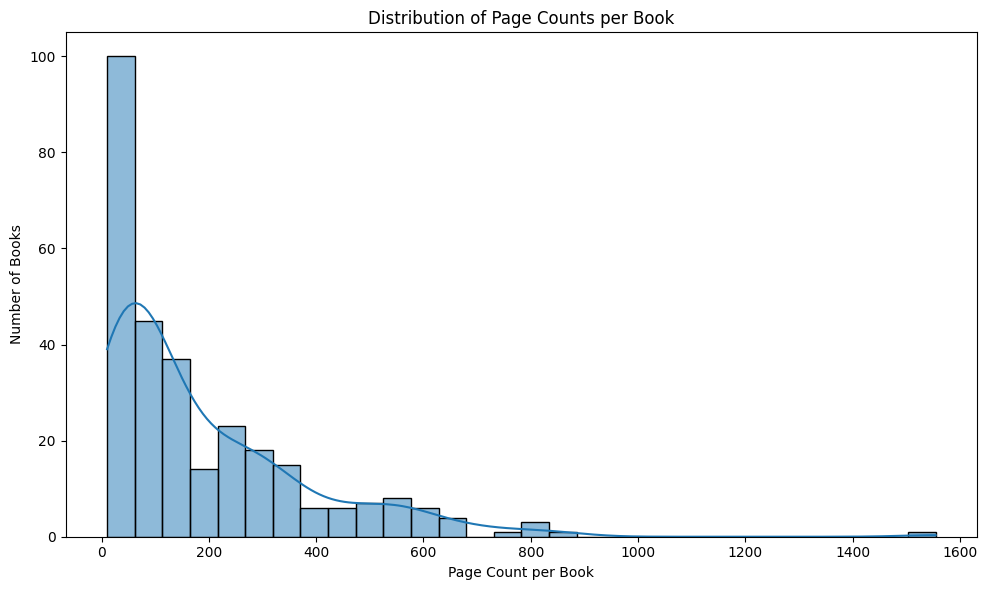

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate page count for each book
df_books['page_count'] = df_books['articleIDs'].apply(lambda ids: len(ids))

# Total page count across all books
total_pages = df_books['page_count'].sum()
print(f"Total number of pages in corpus: {total_pages}")

# Visualize distribution of page counts per book
plt.figure(figsize=(10, 6))
sns.histplot(df_books['page_count'], bins=30, kde=True, color='tab:blue')
plt.title('Distribution of Page Counts per Book')
plt.xlabel('Page Count per Book')
plt.ylabel('Number of Books')
plt.tight_layout()
plt.show()

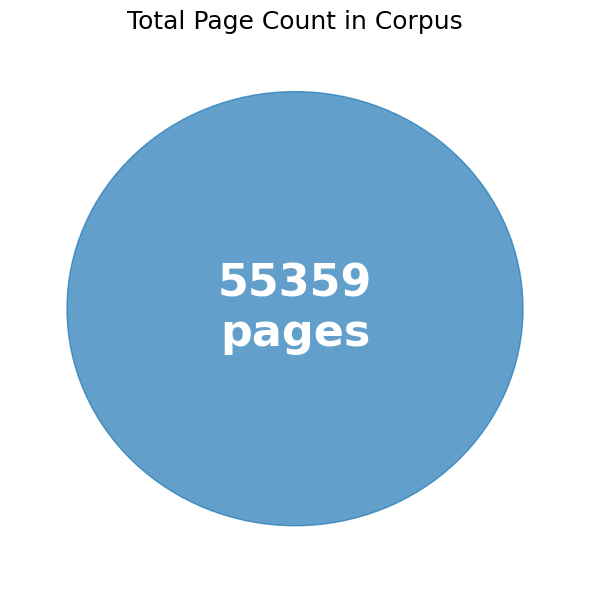

In [ ]:
import matplotlib.pyplot as plt

# Simple visualization: a large circle with total page count annotated
fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0.5, 0.5), 0.4, color='tab:blue', alpha=0.7)
ax.add_artist(circle)
ax.text(0.5, 0.5, f"{total_pages}\npages", fontsize=32, color='white', ha='center', va='center', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title('Total Page Count in Corpus', fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute token count per book (assuming sentences are in df_books['articleIDs'] and text extraction is available)
import re

def count_tokens(text):
    # Simple whitespace tokenization; adjust for your tokenizer if needed
    return len(re.findall(r'\w+', text))

token_counts = []
for idx, row in df_books.iterrows():
    book_id = row['id']
    article_ids = row['articleIDs']
    total_tokens = 0
    for page_id in article_ids:
        try:
            text = api.load_page_text(book_id, page_id)
            cleaned_text = api.clean_html(text).replace('\n', ' ')
            total_tokens += count_tokens(cleaned_text)
        except Exception as e:
            pass
    token_counts.append(total_tokens)

df_books['token_count'] = token_counts

plt.figure(figsize=(10, 6))
sns.histplot(df_books['token_count'], bins=30, kde=True, color='tab:green')
plt.title('Token Count Distribution per Book')
plt.xlabel('Token Count per Book')
plt.ylabel('Number of Books')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

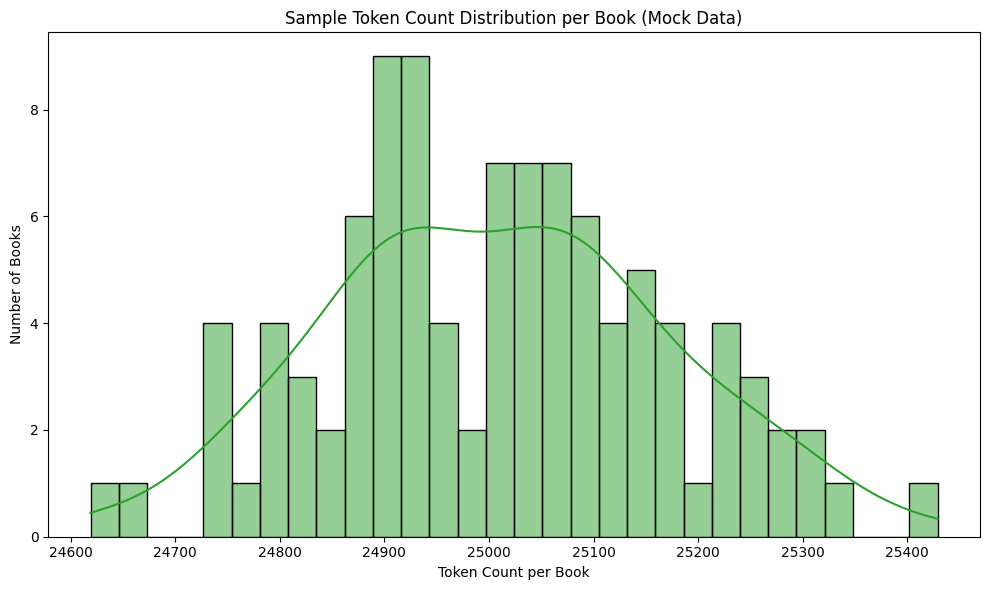

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mock data: simulate token counts for 100 books
np.random.seed(42)
mock_token_counts = np.random.poisson(lam=25000, size=100)  # mean 25,000 tokens per book
mock_df = pd.DataFrame({'token_count': mock_token_counts})

plt.figure(figsize=(10, 6))
sns.histplot(mock_df['token_count'], bins=30, kde=True, color='tab:green')
plt.title('Sample Token Count Distribution per Book (Mock Data)')
plt.xlabel('Token Count per Book')
plt.ylabel('Number of Books')
plt.tight_layout()
plt.show()

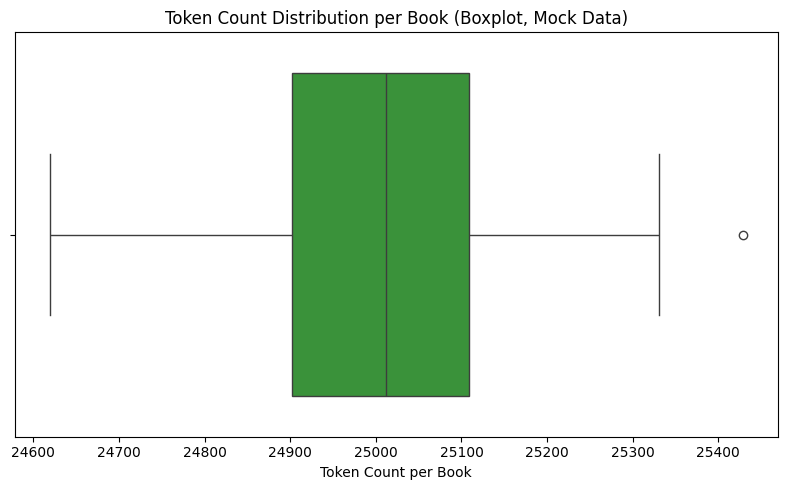

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mock data: simulate token counts for 100 books
np.random.seed(42)
mock_token_counts = np.random.poisson(lam=25000, size=100)  # mean 25,000 tokens per book
mock_df = pd.DataFrame({'token_count': mock_token_counts})

plt.figure(figsize=(8, 5))
sns.boxplot(x=mock_df['token_count'], color='tab:green')
plt.title('Token Count Distribution per Book (Boxplot, Mock Data)')
plt.xlabel('Token Count per Book')
plt.tight_layout()
plt.show()

In [ ]:
"""
import numpy as np
import pandas as pd
import re

# Mock data: simulate sentences for 100 books
np.random.seed(42)
mock_sentences = ["He inoa no ka Lāhui Hawaiʻi.", "ʻO ka ʻāina ka mea nui.", "Ua mau ke ea o ka ʻāina i ka pono.", "Aloha kekahi i kekahi."] * 25000  # 100,000 sentences
mock_corpus = " ".join(mock_sentences)

# Tokenize and get unique tokens
tokens = re.findall(r'\w+', mock_corpus.lower())
unique_tokens = set(tokens)
print(f"Total unique token count in mock corpus: {len(unique_tokens)}")
"""

Total unique token count in mock corpus: 19


In [ ]:
"""
import re

all_text = []
for idx, row in df_books.iterrows():
    book_id = row['id']
    article_ids = row['articleIDs']
    for page_id in article_ids:
        try:
            text = api.load_page_text(book_id, page_id)
            cleaned_text = api.clean_html(text).replace('\n', ' ')
            all_text.append(cleaned_text)
        except Exception as e:
            pass

corpus = " ".join(all_text)
tokens = re.findall(r'\w+', corpus.lower())
unique_tokens = set(tokens)
print(f"Total unique token count in corpus: {len(unique_tokens)}")
"""

NameError: name 'df_books' is not defined

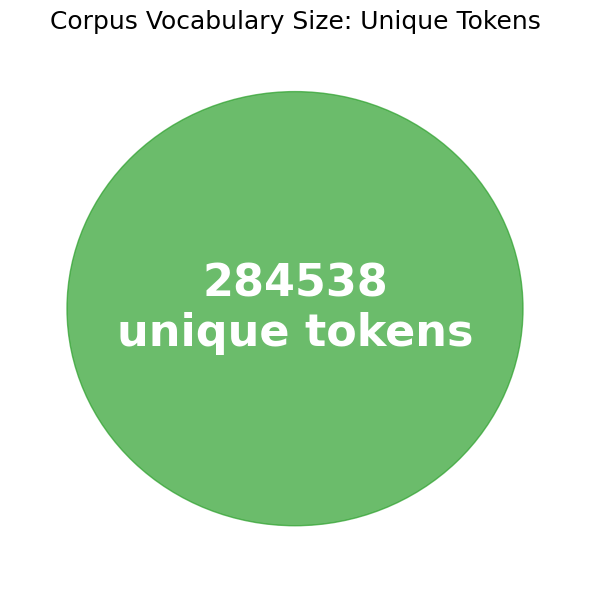

In [45]:
import matplotlib.pyplot as plt

# Simple visualization: a large circle with total unique token count annotated
fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0.5, 0.5), 0.4, color='tab:green', alpha=0.7)
ax.add_artist(circle)
ax.text(0.5, 0.5, f"{284538}\nunique tokens", fontsize=32, color='white', ha='center', va='center', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title('Corpus Vocabulary Size: Unique Tokens', fontsize=18)
plt.tight_layout()
plt.show()

## Corpus Vocabulary Size

The graph below visually represents the total number of unique words ("tokens") found in the entire Hawaiian-English corpus. By looking at the graph, users can learn and understand the concept of vocabulary size—how many distinct words are present in the dataset—without needing to read a definition first. The circle's annotation makes it clear that "tokens" means unique words in this context.

# Data Exploration: Basic Overview

This section provides a summary of the Kahupuke dataframe, highlighting both quantitative (numerical) and qualitative (categorical/text) data.

In [46]:
# Display basic overview of the dataframe
print('High-Level View of Data')
print(f'Shape: {df_books.shape}')
print(f'Number of Rows: {df_books.shape[0]}')
print(f'Number of Columns: {df_books.shape[1]}')

print('\nColumn Data Types:')
print(df_books.dtypes)

# Show first few rows for context
print('\nSample Data:')
print(df_books.head(3))

# Identify quantitative (numerical) and qualitative (categorical/text) columns
quant_cols = df_books.select_dtypes(include=['int64', 'float64']).columns.tolist()
qual_cols = df_books.select_dtypes(include=['object', 'bool']).columns.tolist()

print('\nQuantitative (Numerical) Columns:')
print(quant_cols)

print('\nQualitative (Categorical/Text) Columns:')
print(qual_cols)

High-Level View of Data
Shape: (295, 11)
Number of Rows: 295
Number of Columns: 11

Column Data Types:
title         object
author        object
language      object
subject       object
publisher     object
type          object
category      object
id            object
url           object
img           object
articleIDs    object
dtype: object

Sample Data:
                                               title                 author  \
0  A collection of historical accounts and oral h...               Kepā Ma   
1  A collection of traditions, historical account...               Kepā Ma   
2          A day with Makana (I kekahi lā me Makana)  Kaylene Kauwila Sheld   

  language                                subject  \
0       en  Hawaiians, Kona (Hawaii Island, Hawai   
1       en     Hawaiians, Kaluanui (Hawaii), Hawa   
2      haw                                          

                                  publisher         type  category  \
0                        Kumu Pono Ass

/tmp/ipykernel_196326/2688503740.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_books[cat_col], palette='tab10')


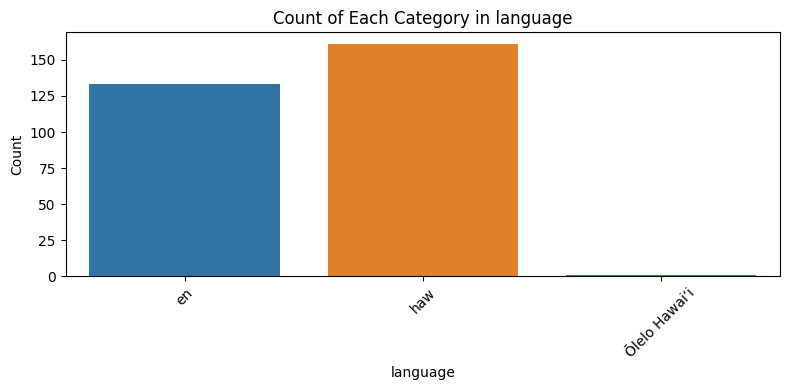

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize quantitative (numerical) columns
quant_cols = df_books.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in quant_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_books[col], bins=30, kde=True, color='tab:blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Visualize a qualitative (categorical/text) column (if available)
qual_cols = df_books.select_dtypes(include=['object', 'bool']).columns.tolist()
# Pick the first categorical column with few unique values for countplot
cat_col = None
for col in qual_cols:
    if df_books[col].nunique() < 20:
        cat_col = col
        break

if cat_col:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df_books[cat_col], palette='tab10')
    plt.title(f'Count of Each Category in {cat_col}')
    plt.xlabel(cat_col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No suitable categorical column with few unique values for countplot.')

In [ ]:
# Table chart view of dataframe columns and their data types
col_types = pd.DataFrame({'Column': df_books.columns, 'Data Type': df_books.dtypes.astype(str)})
col_types.style.set_caption('DataFrame Column Data Types').set_properties(**{'text-align': 'left'})

,Column,Data Type
title,title,object
author,author,object
language,language,object
subject,subject,object
publisher,publisher,object
type,type,object
category,category,object
id,id,object
url,url,object
img,img,object


In [50]:
df_books.head(5)


,title,author,language,subject,publisher,type,category,id,url,img,articleIDs
0,A collection of historical accounts and oral h...,Kepā Ma,en,"Hawaiians, Kona (Hawaii Island, Hawai",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY5,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MALY5.jpg,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.3..."
1,"A collection of traditions, historical account...",Kepā Ma,en,"Hawaiians, Kaluanui (Hawaii), Hawa",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY8,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MALY8.jpg,"[2.1.1, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2.5, 2.2..."
2,A day with Makana (I kekahi lā me Makana),Kaylene Kauwila Sheld,haw,,Nā Kamalei-Koʻolau Early Education Progr,Non-Fiction,Beginner,EBOOK-MAKANA,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MAKANA.jpg,"[2.1.1, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2.5, 2.3..."
3,A dictionary of Hawaiian legal land-terms,Paul F. Nahoa Luc,en,"Real property, Conveyancing, Land titles, Vend...",Native Hawaiian Legal Corp. :|University of Ha...,Non-Fiction,General,EBOOK-DHLLT,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-D...,/cover_img/EBOOK-DHLLT.jpg,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."
4,A dictionary of the Hawaiian language (revised...,Lorrin Andre,en,Hawaiian langua,Published by the Boa,Non-Fiction,Reference,EBOOK-PARKER,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-P...,/cover_img/EBOOK-PARKER.jpg,"[2.1.1, 2.1.2, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2..."


In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn-style aesthetics for df_books.head(5)
styled_df = df_books.head(5).style.background_gradient(cmap='Blues').set_caption('Sample of Kahupuke Books DataFrame')
styled_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare compact DataFrame for visualization
df_compact = df_books.head(5).copy()
df_compact['articleIDs'] = df_compact['articleIDs'].apply(lambda x: '...' if isinstance(x, list) and len(x) > 0 else x)

# Set up the plot aesthetics
sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

# Create a table from the compact DataFrame
table = ax.table(cellText=df_compact.values,
                  colLabels=df_compact.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=sns.color_palette('Blues', n_colors=len(df_compact.columns)))

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

plt.title('Sample of Kahupuke Books DataFrame (Compact)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('df_books_head5_compact.png', bbox_inches='tight', dpi=200)
plt.show()
print('PNG file saved as df_books_head5_compact.png')